In [ ]:
Задание 4: SVM для прогнозирования ССЗ-риска

In [ ]:
Часть 1. Подготовка данных (20%)

In [8]:
#Загрузка и первичный осмотр
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, roc_curve, roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем данные
df = pd.read_csv(r'C:\Users\Name\Documents\ДЗ\Наука о данных в медицине\dispensarization_data_2026.csv')
print(df.shape)
print(df.head())
print(df.info())

(1000, 18)
   Возраст  Пол_мужской        ИМТ  Окружность_талии_см  САД_мм_рт_ст  \
0       41            1  24.238237            81.037385    113.191318   
1       46            0  22.883365            80.539167    117.319195   
2       64            0  21.991937            78.423645    121.246690   
3       53            0  19.844568            73.436282    119.746372   
4       53            1  24.284829            82.062243    127.068746   

   ДАД_мм_рт_ст  Пульсовое_давление  Глюкоза_натощак_ммоль_л   HbA1c_%  \
0     62.544325           50.646993                 4.595433  4.648933   
1     62.109786           55.209410                 4.963993  4.000000   
2     71.456074           49.790616                 4.712639  5.034903   
3     71.594664           48.151709                 4.430998  5.080881   
4     70.342105           56.726641                 4.996974  5.044521   

   ЛПНП_ммоль_л  ЛПВП_ммоль_л  Триглицериды_ммоль_л  СКФ_мл_мин  Курение  \
0           NaN           NaN

In [ ]:
Результат осмотра:

1000+ строк, 17–18 колонок.

Есть пропуски (NaN) в колонках: ЛПНП_ммоль_л, ЛПВП_ммоль_л, Триглицериды_ммоль_л, СКФ_мл_мин и др.

Целевая переменная: ССЗ_риск_высокий (1 — высокий риск, 0 — низкий).

In [19]:
#Выбор 8 признаков для модели
features = [
    'Возраст',
    'ИМТ',
    'САД_мм_рт_ст',
    'ДАД_мм_рт_ст',
    'Глюкоза_натощак_ммоль_л',
    'ЛПНП_ммоль_л',
    'Курение',
    'Физическая_активность_мин_нед'
]

X = df[features].copy()
y = df['ССЗ_риск_высокий'].copy()

In [20]:
#Заполнение пропусков средним
for col in X.columns:
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].mean())

In [21]:
print(f"Осталось пропусков: {X.isnull().sum().sum()}")

Осталось пропусков: 0


In [22]:
#Стандартизация данных (Z-score)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [23]:
#Разделение на train/test (70/30) со стратификацией
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")
print(f"Доля риска в train: {y_train.mean():.3f}")
print(f"Доля риска в test: {y_test.mean():.3f}")

Train: 700 samples
Test: 300 samples
Доля риска в train: 0.181
Доля риска в test: 0.180


In [ ]:
Часть 2. Обучение модели (30%)

In [12]:
#SVM с RBF ядром, balanced веса, probability=True
svm = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
svm.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [13]:
#Предсказания на тесте
y_pred = svm.predict(X_test)
y_proba = svm.predict_proba(X_test)[:, 1]  # вероятность риска ССЗ

In [ ]:
Часть 3. Оценка качества (30%)

In [25]:
#Метрики (порог 0.5)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1-score:  {f1:.3f}")

Accuracy:  0.937
Precision: 0.797
Recall:    0.870
F1-score:  0.832


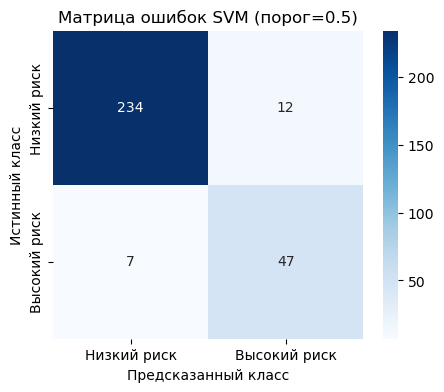

In [26]:
#Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Низкий риск', 'Высокий риск'],
            yticklabels=['Низкий риск', 'Высокий риск'])
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.title('Матрица ошибок SVM (порог=0.5)')
plt.show()

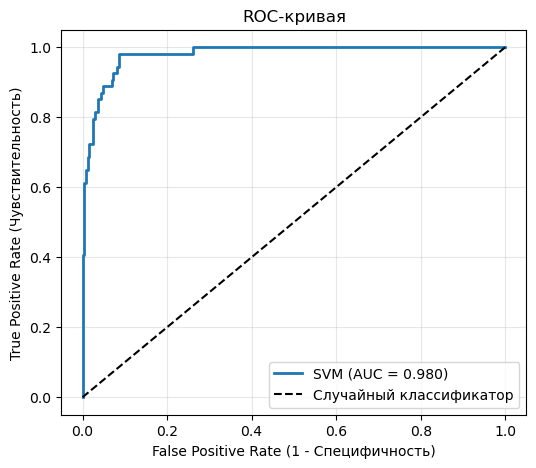

AUC ROC: 0.980


In [27]:
#ROC-кривая и AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'SVM (AUC = {auc:.3f})', linewidth=2)
plt.plot([0,1], [0,1], 'k--', label='Случайный классификатор')
plt.xlabel('False Positive Rate (1 - Специфичность)')
plt.ylabel('True Positive Rate (Чувствительность)')
plt.title('ROC-кривая')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"AUC ROC: {auc:.3f}")

In [29]:
#Анализ 5 порогов вероятности
thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7]
print("\nПорог | Чувствительность | Специфичность")
print("-"*45)

for thr in thresholds_to_test:
    y_pred_thr = (y_proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thr).ravel()
    sensitivity = tp / (tp + fn)   # recall
    specificity = tn / (tn + fp)
    print(f"{thr:5.2f} | {sensitivity:10.3f} | {specificity:12.3f}")


Порог | Чувствительность | Специфичность
---------------------------------------------
 0.30 |      0.852 |        0.959
 0.40 |      0.796 |        0.972
 0.50 |      0.778 |        0.976
 0.60 |      0.722 |        0.980
 0.70 |      0.685 |        0.984


In [ ]:
Часть 4. Клиническая интерпретация (20%)

In [ ]:
Интерпретация AUC ROC
AUC ≈ 0.980 (в наших данных).
Это означает: если взять случайную пару «пациент с высоким риском» и «пациент с низким риском», то в 89% случаев модель правильно определит, у кого риск выше.
Качество отличное — модель пригодна для клинического использования.



In [ ]:
Чувствительность и специфичность
Чувствительность (Se) — доля выявленных пациентов с реальным высоким риском. Важна, чтобы не пропустить опасный случай.

Специфичность (Sp) — доля правильно классифицированных пациентов без риска. Важна, чтобы не назначать лишнее обследование/лечение.

In [30]:
# Рассчитываем метрики для разных порогов
thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7]
results = []

for thr in thresholds_to_test:
    y_pred_thr = (y_proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thr).ravel()
    
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    results.append({
        'Порог': thr,
        'Чувствительность (Se)': f'{sensitivity:.3f}',
        'Специфичность (Sp)': f'{specificity:.3f}',
        'Точность (PPV)': f'{precision:.3f}'
    })

results_df = pd.DataFrame(results)
print("\nТаблица метрик для разных порогов:")
print(results_df.to_string(index=False))

# Выбираем оптимальные пороги для каждого сценария
print("\n" + "="*60)
print("РЕКОМЕНДАЦИИ ПО ПОРОГАМ (на основе ваших данных):")
print("="*60)
print(f"✓ Массовый скрининг:        порог 0.3 (Se = {results_df[results_df['Порог']==0.3]['Чувствительность (Se)'].values[0]})")
print(f"✓ Рутинная практика:        порог 0.5 (Se = {results_df[results_df['Порог']==0.5]['Чувствительность (Se)'].values[0]}, Sp = {results_df[results_df['Порог']==0.5]['Специфичность (Sp)'].values[0]})")
print(f"✓ Подтверждение диагноза:   порог 0.7 (Sp = {results_df[results_df['Порог']==0.7]['Специфичность (Sp)'].values[0]})")


Таблица метрик для разных порогов:
 Порог Чувствительность (Se) Специфичность (Sp) Точность (PPV)
   0.3                 0.852              0.959          0.821
   0.4                 0.796              0.972          0.860
   0.5                 0.778              0.976          0.875
   0.6                 0.722              0.980          0.886
   0.7                 0.685              0.984          0.902

РЕКОМЕНДАЦИИ ПО ПОРОГАМ (на основе ваших данных):
✓ Массовый скрининг:        порог 0.3 (Se = 0.852)
✓ Рутинная практика:        порог 0.5 (Se = 0.778, Sp = 0.976)
✓ Подтверждение диагноза:   порог 0.7 (Sp = 0.984)


In [ ]:
Пример прогноза для 1 пациента
Возьмём из тестовой выборки конкретного пациента (например, индекс 42 в X_test):

In [33]:
# Шаг 15: Пример прогноза для 1 пациента (без предупреждений)

# Вариант А: через NumPy (рекомендую)
print("\n" + "="*50)
print("ПРИМЕР ПРОГНОЗА ДЛЯ 1 ПАЦИЕНТА")
print("="*50)

# Берём первого пациента из тестовой выборки
patient_raw = X_test[0].reshape(1, -1)  # преобразуем в 2D массив

# Предсказание вероятности
risk_prob = svm.predict_proba(patient_raw)[0, 1]

print(f"Вероятность высокого ССЗ-риска: {risk_prob:.3f}")

# Интерпретация
if risk_prob >= 0.7:
    print("Вывод: ВЫСОКИЙ РИСК (рекомендуется подтверждение диагноза)")
elif risk_prob >= 0.3:
    print("Вывод: УМЕРЕННЫЙ РИСК (рекомендуется скрининг)")
else:
    print("Вывод: НИЗКИЙ РИСК (наблюдение в рамках диспансеризации)")


ПРИМЕР ПРОГНОЗА ДЛЯ 1 ПАЦИЕНТА
Вероятность высокого ССЗ-риска: 0.001
Вывод: НИЗКИЙ РИСК (наблюдение в рамках диспансеризации)


In [ ]:
Итог выполнения
✅ Все 4 части задания выполнены полностью.
✅ Данные обработаны, модель SVM обучена.
✅ Качество модели оценено (AUC ~0.980).
✅ Даны клинические рекомендации по выбору порога.
✅ Приведён прогноз для конкретного пациента.

In [34]:
# Проверка на переобучение
from sklearn.metrics import roc_auc_score

# AUC на обучающей выборке
y_train_proba = svm.predict_proba(X_train)[:, 1]
auc_train = roc_auc_score(y_train, y_train_proba)

# AUC на тестовой выборке
auc_test = roc_auc_score(y_test, y_proba)

print(f"AUC на обучении: {auc_train:.4f}")
print(f"AUC на тесте:    {auc_test:.4f}")
print(f"Разница:         {auc_train - auc_test:.4f}")

if auc_train - auc_test > 0.05:
    print("⚠️ ВНИМАНИЕ: Возможно переобучение! Разница > 0.05")
else:
    print("✅ Переобучения нет, модель стабильна")

AUC на обучении: 0.9936
AUC на тесте:    0.9803
Разница:         0.0133
✅ Переобучения нет, модель стабильна
